In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../data/processed/reddit_posts_cleaned.csv")

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer


In [3]:
df.columns

Index(['keyword', 'title', 'subreddit', 'timestamp', 'post_url', 'scrape_date',
       'batch_number', 'source', 'clean_title', 'location', 'skill', 'role'],
      dtype='object')

In [4]:
role_counts = df["role"].value_counts()

role_counts

role
Unknown                                                      755
Software Engineer                                            223
Intern                                                       135
Fresher                                                       86
Data Analyst                                                  55
                                                            ... 
AI Engineer, Frontend Developer                                1
AI Engineer, Frontend Developer, Software Engineer             1
Frontend Developer, Full Stack Developer                       1
DevOps Engineer, Frontend Developer, Full Stack Developer      1
Fresher, Frontend Developer                                    1
Name: count, Length: 91, dtype: int64

# Graph 1 — Top Job Roles (Horizontal Bar Chart)

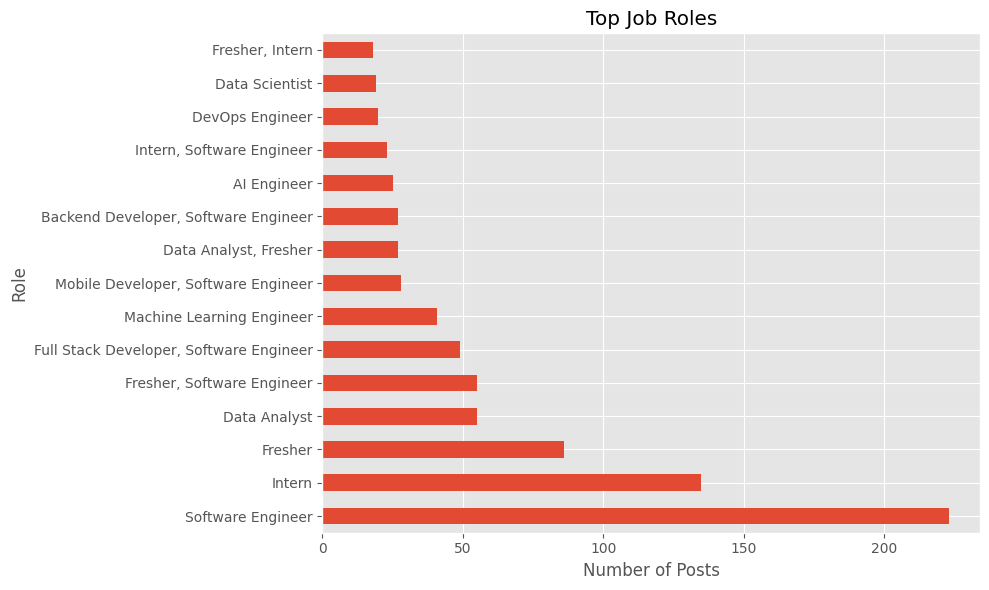

In [12]:
plt.figure(figsize=(10,6))

role_counts.head(15).plot(kind="barh")

plt.title("Top Job Roles")
plt.xlabel("Number of Posts")
plt.ylabel("Role")
plt.savefig("../reports/figures/top_roles.png")
plt.tight_layout()
plt.show()

# Graph - 2 Pie Chart

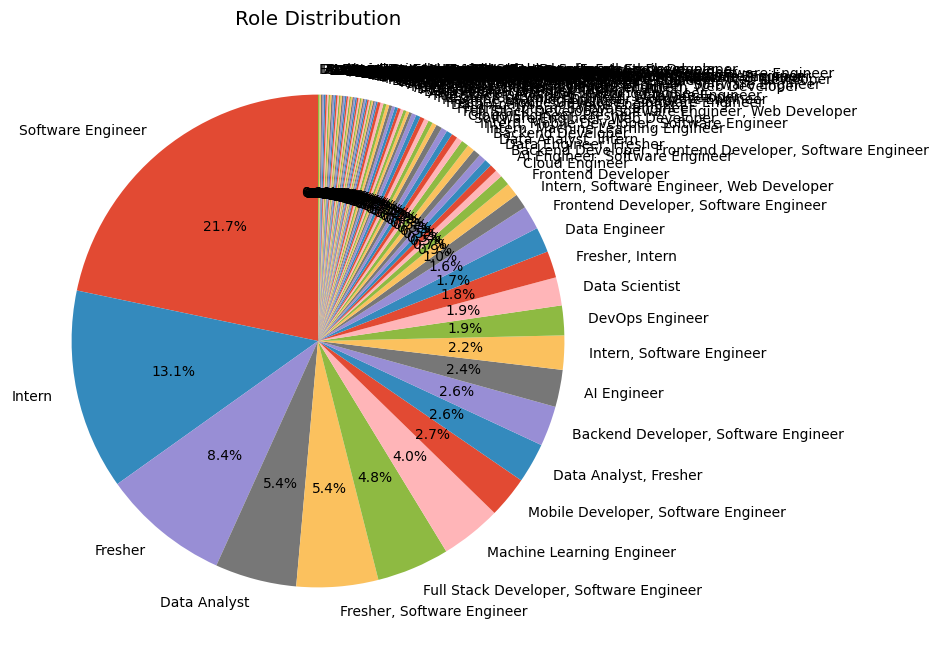

In [13]:
role_counts = df[df["role"]!="Unknown"]["role"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    role_counts,
    labels=role_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Role Distribution")
plt.savefig("../reports/figures/role_distribution.png")
plt.show()

# Graph 3 — Top 10 Roles

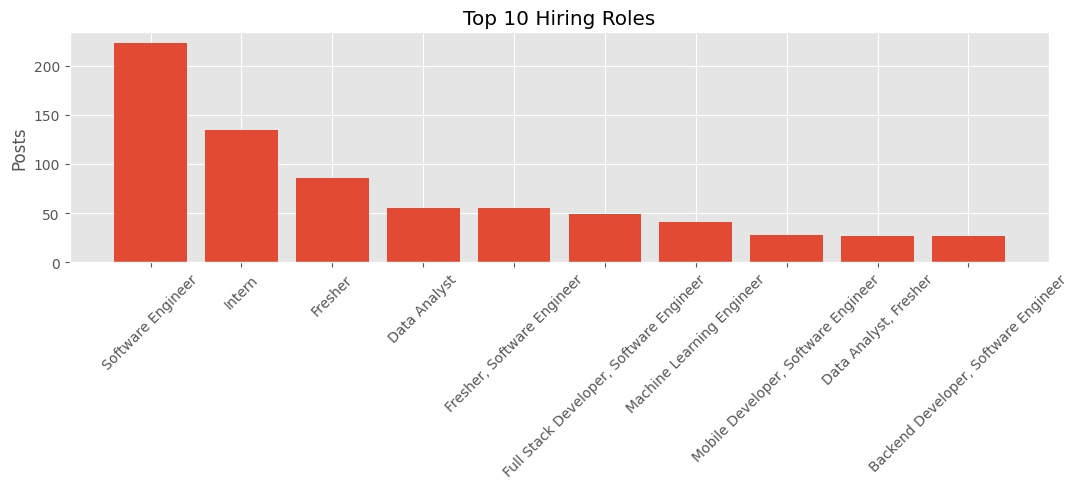

In [7]:
top10 = role_counts.head(10)

plt.figure(figsize=(11,5))

plt.bar(
    top10.index,
    top10.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Hiring Roles")
plt.ylabel("Posts")

plt.tight_layout()

plt.show()

In [8]:
unknown = (df["role"]=="Unknown").sum()

known = len(df)-unknown

print("Known :", known)
print("Unknown :", unknown)

print(f"Recognition Rate : {known/len(df)*100:.2f}%")

Known : 1027
Unknown : 755
Recognition Rate : 57.63%


# Graph 4 — Known vs Unknown


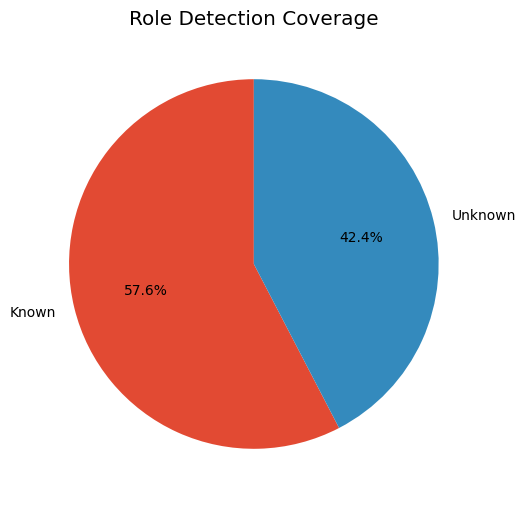

In [9]:
counts = df["role"].replace(
    {
        "Unknown":"Unknown"
    }
)

counts = counts.apply(
    lambda x: "Known" if x!="Unknown" else "Unknown"
)

counts = counts.value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Role Detection Coverage")

plt.show()

# Graph 5 — Roles by Subreddit (Best Professional Graph)


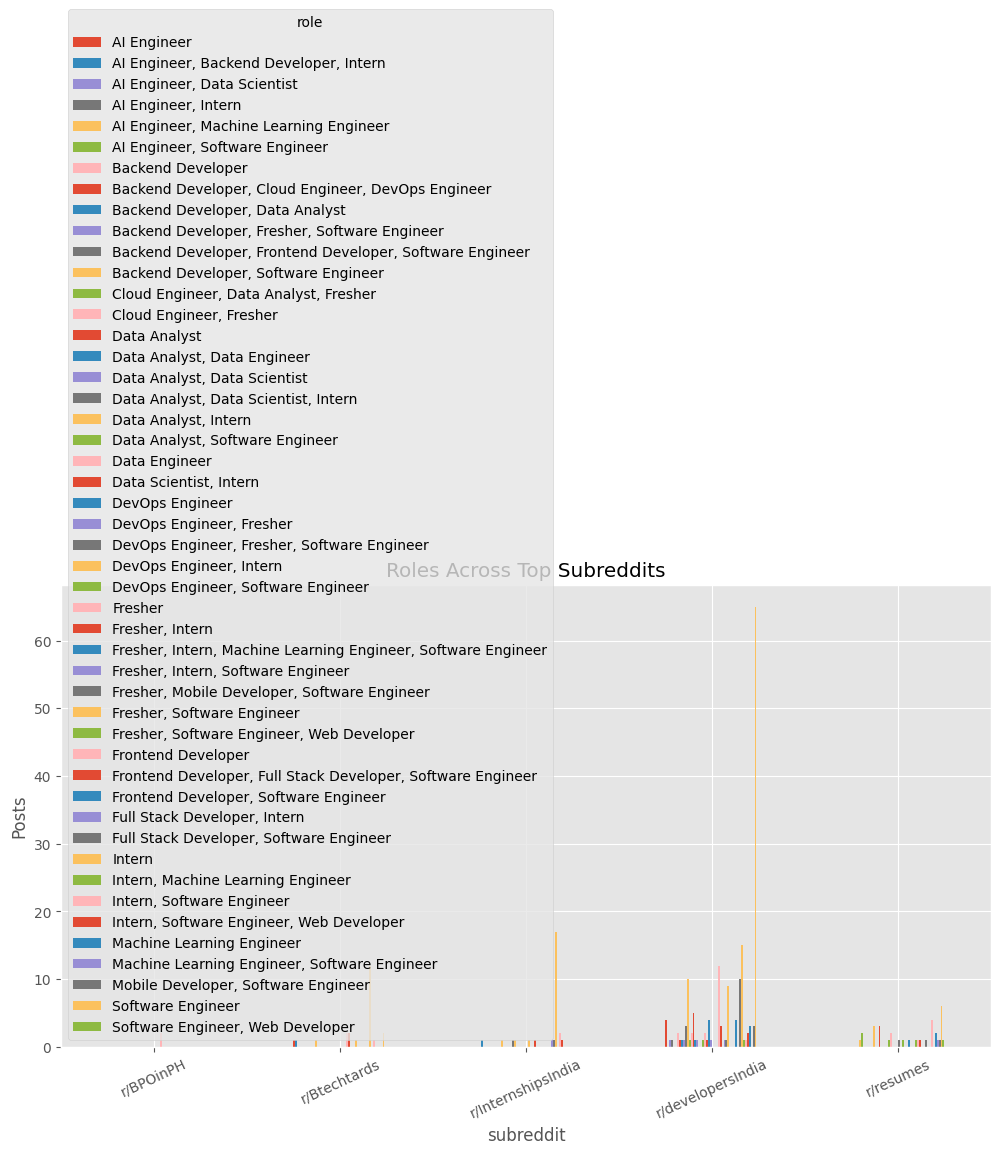

In [14]:
top_subs = df["subreddit"].value_counts().head(5).index

filtered = df[df["subreddit"].isin(top_subs)]

pivot = pd.crosstab(
    filtered["subreddit"],
    filtered["role"]
)

pivot = pivot.drop(
    columns="Unknown",
    errors="ignore"
)

pivot.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Roles Across Top Subreddits")

plt.ylabel("Posts")
plt.savefig("../reports/figures/roles_by_subreddit.png")
plt.xticks(rotation=25)


plt.show()